In [ ]:
import pandas as pd

# Load the cleaned crime dataset
crime_df = pd.read_csv("final_cleaned_crime_dataset.csv")

# Check the structure briefly
print("Original shape:", crime_df.shape)
print("\nOriginal columns:")
print(crime_df.columns)

# Make sure the date column is in datetime format
crime_df["date"] = pd.to_datetime(crime_df["date"])

# Combine Kings Cross St Pancras into Kings Cross
# This avoids splitting the same London hub into two separate categories
crime_df["station"] = crime_df["station"].replace({
    "Kings Cross St Pancras": "Kings Cross"
})

# Create a month variable for modelling
crime_df["month"] = crime_df["date"].dt.month

# Keep only the variables needed for the logistic regression base dataset
# We are not keeping crime_type because disorder_flag was created from it,
# and using it later would create leakage in the model
crime_model_df = crime_df[["date", "station", "month", "disorder_flag"]].copy()

# Final checks
print("\nCleaned crime dataset shape:", crime_model_df.shape)
print("\nPreview of cleaned crime modelling dataset:")
print(crime_model_df.head())

print("\nStation counts after standardisation:")
print(crime_model_df["station"].value_counts())

print("\nMissing values check:")
print(crime_model_df.isnull().sum())

Original shape: (621, 6)

Original columns:
Index(['date', 'lon', 'lat', 'crime_type', 'disorder_flag', 'station'], dtype='object')

Cleaned crime dataset shape: (621, 4)

Preview of cleaned crime modelling dataset:
        date      station  month  disorder_flag
0 2024-02-01  Kings Cross      2              0
1 2024-02-01  Kings Cross      2              0
2 2024-02-01  Kings Cross      2              0
3 2024-02-01  Kings Cross      2              0
4 2024-02-01  Kings Cross      2              0

Station counts after standardisation:
station
Kings Cross           284
Leeds                 128
Newcastle Central     123
Edinburgh Waverley     86
Name: count, dtype: int64

Missing values check:
date             0
station          0
month            0
disorder_flag    0
dtype: int64


In [ ]:
import pandas as pd

# Load the weather dataset
weather_df = pd.read_excel("weather clean.xlsx")

# Check the structure briefly
print("Original shape:", weather_df.shape)
print("\nOriginal columns:")
print(weather_df.columns)

# Rename columns where needed
weather_df = weather_df.rename(columns={
    "Stations ": "station",
    "Date": "date"
})

# Convert date column to datetime
weather_df["date"] = pd.to_datetime(weather_df["date"])

# Standardise station names so they match the crime dataset
weather_df["station"] = weather_df["station"].replace({
    "London Kings Cross": "Kings Cross",
    "Newcastle": "Newcastle Central",
    "Edinburgh": "Edinburgh Waverley"
})

# Convert temperature from Fahrenheit to Celsius
weather_df["temperature_avg"] = (weather_df["temperature_avg"] - 32) * 5 / 9

# Convert daily weather dates to monthly dates
weather_df["date"] = weather_df["date"].dt.to_period("M").dt.to_timestamp()

# Aggregate to monthly station-level weather
weather_monthly_df = (
    weather_df
    .groupby(["date", "station"], as_index=False)
    .agg({
        "temperature_avg": "mean",
        "humidity_avg": "mean",
        "precipitation": "mean"
    })
)

# Rename temperature column for clarity
weather_monthly_df = weather_monthly_df.rename(columns={
    "temperature_avg": "temperature_avg_c"
})

# Final checks
print("\nCleaned monthly weather dataset shape:", weather_monthly_df.shape)
print("\nPreview of cleaned monthly weather dataset:")
print(weather_monthly_df.head())

print("\nStation counts after standardisation:")
print(weather_monthly_df["station"].value_counts())

print("\nMissing values check:")
print(weather_monthly_df.isnull().sum())

Original shape: (1464, 5)

Original columns:
Index(['Date', 'temperature_avg', 'humidity_avg', 'precipitation',
       'Stations '],
      dtype='object')

Cleaned monthly weather dataset shape: (48, 5)

Preview of cleaned monthly weather dataset:
        date             station  temperature_avg_c  humidity_avg  \
0 2024-01-01  Edinburgh Waverley           4.139785     84.651613   
1 2024-01-01         Kings Cross           6.044803     76.951613   
2 2024-01-01               Leeds           4.111111     85.829032   
3 2024-01-01   Newcastle Central           4.234767     85.900000   
4 2024-02-01  Edinburgh Waverley           6.181992     84.720690   

   precipitation  
0       0.000000  
1       0.067742  
2       0.000000  
3       0.000000  
4       0.000000  

Station counts after standardisation:
station
Edinburgh Waverley    12
Kings Cross           12
Leeds                 12
Newcastle Central     12
Name: count, dtype: int64

Missing values check:
date                 0
stat

In [ ]:
# Merge the crime and monthly weather datasets
# We use an inner merge so only matching station-month records are kept

merged_df = pd.merge(
    crime_model_df,
    weather_monthly_df,
    on=["date", "station"],
    how="inner"
)

# Final checks
print("Merged dataset shape:", merged_df.shape)

print("\nPreview of merged dataset:")
print(merged_df.head())

print("\nMissing values check:")
print(merged_df.isnull().sum())

print("\nStation counts in merged dataset:")
print(merged_df["station"].value_counts())

print("\nDate range in merged dataset:")
print(merged_df["date"].min(), "to", merged_df["date"].max())

Merged dataset shape: (621, 7)

Preview of merged dataset:
        date      station  month  disorder_flag  temperature_avg_c  \
0 2024-02-01  Kings Cross      2              0           9.308429   
1 2024-02-01  Kings Cross      2              0           9.308429   
2 2024-02-01  Kings Cross      2              0           9.308429   
3 2024-02-01  Kings Cross      2              0           9.308429   
4 2024-02-01  Kings Cross      2              0           9.308429   

   humidity_avg  precipitation  
0      82.57931       0.134483  
1      82.57931       0.134483  
2      82.57931       0.134483  
3      82.57931       0.134483  
4      82.57931       0.134483  

Missing values check:
date                 0
station              0
month                0
disorder_flag        0
temperature_avg_c    0
humidity_avg         0
precipitation        0
dtype: int64

Station counts in merged dataset:
station
Kings Cross           284
Leeds                 128
Newcastle Central     123
Edin

In [ ]:
# Create the final modelling dataset
model_df = merged_df[[
    "station",
    "month",
    "temperature_avg_c",
    "humidity_avg",
    "precipitation",
    "disorder_flag"
]].copy()

# One-hot encode the station column
# This converts station names into numeric columns for logistic regression
model_df = pd.get_dummies(model_df, columns=["station"], drop_first=True)

# Separate features (X) and target (y)
X = model_df.drop(columns=["disorder_flag"])
y = model_df["disorder_flag"]

# Final checks
print("Final modelling dataset shape:", model_df.shape)
print("\nFeature columns:")
print(X.columns)

print("\nPreview of final modelling dataset:")
print(model_df.head())

print("\nTarget distribution:")
print(y.value_counts())

Final modelling dataset shape: (621, 8)

Feature columns:
Index(['month', 'temperature_avg_c', 'humidity_avg', 'precipitation',
       'station_Kings Cross', 'station_Leeds', 'station_Newcastle Central'],
      dtype='object')

Preview of final modelling dataset:
   month  temperature_avg_c  humidity_avg  precipitation  disorder_flag  \
0      2           9.308429      82.57931       0.134483              0   
1      2           9.308429      82.57931       0.134483              0   
2      2           9.308429      82.57931       0.134483              0   
3      2           9.308429      82.57931       0.134483              0   
4      2           9.308429      82.57931       0.134483              0   

   station_Kings Cross  station_Leeds  station_Newcastle Central  
0                 True          False                      False  
1                 True          False                      False  
2                 True          False                      False  
3                

In [ ]:
# Convert any True/False dummy columns into 0/1 integers
X = X.astype(int)

In [ ]:
X = model_df.drop(columns=["disorder_flag"]).copy()
y = model_df["disorder_flag"].copy()

# Convert only boolean columns to integers (leave weather as float)
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

# Check
print(X.dtypes)
print(X.head())

month                          int32
temperature_avg_c            float64
humidity_avg                 float64
precipitation                float64
station_Kings Cross            int64
station_Leeds                  int64
station_Newcastle Central      int64
dtype: object
   month  temperature_avg_c  humidity_avg  precipitation  station_Kings Cross  \
0      2           9.308429      82.57931       0.134483                    1   
1      2           9.308429      82.57931       0.134483                    1   
2      2           9.308429      82.57931       0.134483                    1   
3      2           9.308429      82.57931       0.134483                    1   
4      2           9.308429      82.57931       0.134483                    1   

   station_Leeds  station_Newcastle Central  
0              0                          0  
1              0                          0  
2              0                          0  
3              0                          0  
4         

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# stratify=y keeps the class balance similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Check target balance in training and test sets
print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

X_train shape: (496, 7)
X_test shape: (125, 7)
y_train shape: (496,)
y_test shape: (125,)

Training target distribution:
disorder_flag
0    352
1    144
Name: count, dtype: int64

Test target distribution:
disorder_flag
0    89
1    36
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

# Make copies so the original train/test sets stay untouched
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Select only the continuous weather variables to scale
numeric_cols = ["temperature_avg_c", "humidity_avg", "precipitation"]

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data only, then transform both sets
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Check the result
print("Scaled training data preview:")
print(X_train_scaled.head())

print("\nScaled test data preview:")
print(X_test_scaled.head())

Scaled training data preview:
     month  temperature_avg_c  humidity_avg  precipitation  \
527     11          -0.748527      0.479577       1.090352   
177      5           0.866591     -0.859825       1.303590   
130      4          -0.120848     -1.506243       0.387120   
143      4          -0.120848     -1.506243       0.387120   
362      8           2.002305     -1.747617      -0.261668   

     station_Kings Cross  station_Leeds  station_Newcastle Central  
527                    1              0                          0  
177                    1              0                          0  
130                    1              0                          0  
143                    1              0                          0  
362                    1              0                          0  

Scaled test data preview:
     month  temperature_avg_c  humidity_avg  precipitation  \
504     10          -1.324283      1.031726      -0.738051   
379      8           0.113039   

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the logistic regression model
log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

# Fit the model using the scaled training data
log_model.fit(X_train_scaled, y_train)

print("Logistic regression model fitted successfully.")

Logistic regression model fitted successfully.


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = log_model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.408

Confusion Matrix:
[[34 55]
 [19 17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.38      0.48        89
           1       0.24      0.47      0.31        36

    accuracy                           0.41       125
   macro avg       0.44      0.43      0.40       125
weighted avg       0.52      0.41      0.43       125



Model Performance Table:
                 Metric  Value
0              Accuracy  0.408
1  Precision (Disorder)  0.236
2     Recall (Disorder)  0.472
3   F1-score (Disorder)  0.315


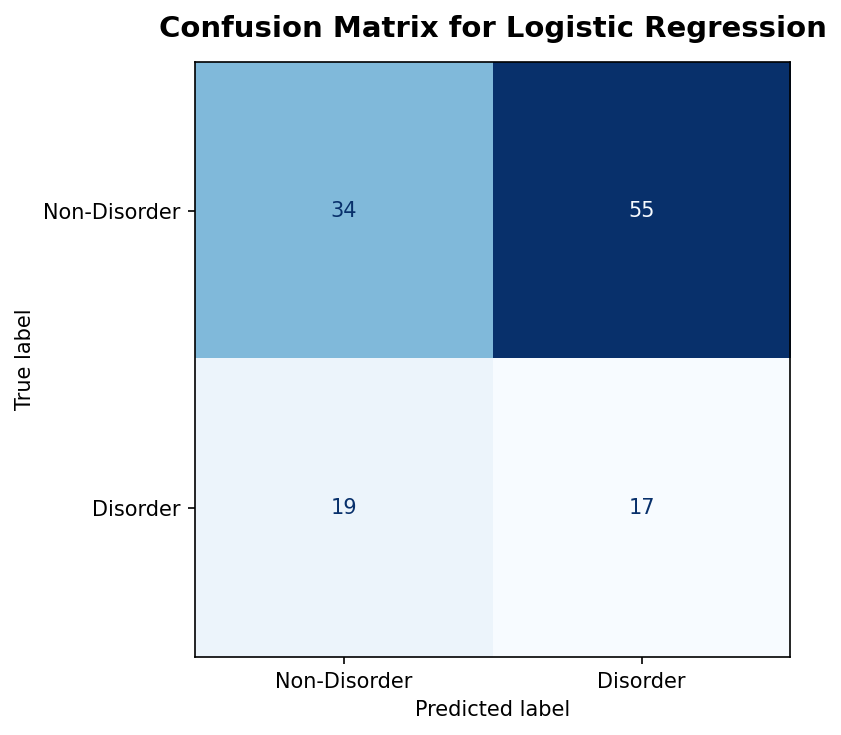


Logistic Regression Coefficients:
                     Feature  Coefficient
6  station_Newcastle Central     0.695661
4        station_Kings Cross     0.592828
5              station_Leeds     0.581852
1          temperature_avg_c     0.106820
0                      month     0.012744
2               humidity_avg     0.008858
3              precipitation    -0.051659


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# -------------------------------
# 1. Predictions
# -------------------------------

y_pred = log_model.predict(X_test_scaled)

# -------------------------------
# 2. Basic metrics
# -------------------------------

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

# Build a clean metrics table
metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Disorder)", "Recall (Disorder)", "F1-score (Disorder)"],
    "Value": [
        round(accuracy, 3),
        round(report["1"]["precision"], 3),
        round(report["1"]["recall"], 3),
        round(report["1"]["f1-score"], 3)
    ]
})

print("Model Performance Table:")
print(metrics_table)

# Save metrics table to CSV for report use if needed
metrics_table.to_csv("/content/logistic_regression_metrics_table.csv", index=False)

# -------------------------------
# 3. Confusion matrix
# -------------------------------

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Disorder", "Disorder"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title("Confusion Matrix for Logistic Regression", fontsize=14, weight="bold", pad=12)
plt.tight_layout()
plt.savefig("/content/logistic_regression_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# -------------------------------
# 4. Coefficients table
# -------------------------------

coefficients_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

# Sort by coefficient value for easier interpretation
coefficients_table = coefficients_table.sort_values("Coefficient", ascending=False)

print("\nLogistic Regression Coefficients:")
print(coefficients_table)

# Save coefficients table
coefficients_table.to_csv("/content/logistic_regression_coefficients.csv", index=False)

In [ ]:
merged_df.to_csv("/content/final_merged_dataset.csv", index=False)